/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_10646/4055148932.py:71: RuntimeWarning: Mean of empty slice
  i1_per_time = np.nanmean(i1_per_time, axis=-1)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


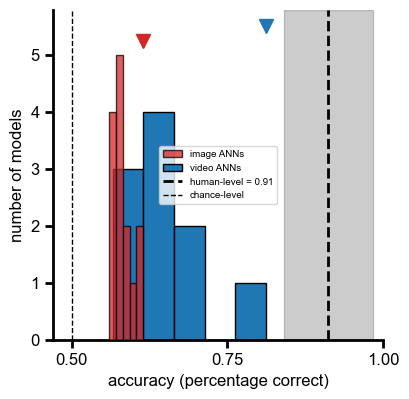

image ANNs mean accuracy: 0.58 ± 0.02
video ANNs mean accuracy: 0.65 ± 0.06
image ANNs - video ANNs mean difference: -0.07
image ANNs max accuracy: 0.61
video ANNs max accuracy: 0.81
t-test between image and video ANNs: TtestResult(statistic=np.float64(-3.6563682307770127), pvalue=np.float64(0.0013891195119961925), df=np.float64(22.0))


In [1]:
"""
Behavioral Decoding Analysis of Object Motion Direction for ANN models

This script visualizes histograms of models based on their behavioral performance. It processes pre-computed accuracy scores.

The analysis includes:
1. Loading accuracy scores from HDF5 file
2. Computing the highest accuracy across time bins for each model
3. Generating a histogram comparing static (image-based) vs dynamic (video-based) ANN models, with vertical lines indicating mean performance for each group and chance-level performance.

Key outputs:
- decode_obj_dir_linear_model_histogram.pdf: Histogram comparing model performance on object motion direction decoding task, with mean performance indicated for static vs dynamic models.
"""

import sys
sys.path.append('../')

from utils.plot_utils import journal_figure_pdf, journal_figure

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy

import scienceplots

plt.style.use(['nature'])

static_models = {
    "images_moving2_alexnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'AlexNet'], 
    "images_moving2_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
    "images_moving2_densenet121_features_srp_1000_10.h5" : ['f', 'tab:red', 'DenseNet-121'], 
    "images_moving2_efficientnet_b0_features_srp_1000_10.h5" : ['f', 'tab:red', 'EfficientNet-B0'], 
    "images_moving2_hiera_features_srp_1000_10.h5" : ['f', 'tab:red', 'Hiera'], 
    "images_moving2_inception_v3_features_srp_1000_10.h5" : ['f', 'tab:red', 'Inception-V3'], 
    "images_moving2_pnasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'PNASNet'], 
    "images_moving2_resnet50_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50'], 
    "images_moving2_resnet50_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50-SSL'], 
    "images_moving2_vit_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT'], 
    "images_moving2_vit_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT-SSL'], 
    "images_moving2_nasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'NASNet'], 
    "images_moving2_rgc_intermediate_features_ff_srp_1000_10.h5" : ['ri', 'tab:red', 'ConvRNN-F'],
    "images_moving2_CORnet-S_IT_features_srp_1000_10.h5" : ['ri', 'tab:red', 'CORnet-S'],
}

dynamic_models = {
    "images_moving2_c2d_r50-blocks.4.res_blocks.5.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving2_i3d_r50-blocks.5.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving2_x3d_xs-blocks.4.res_blocks.6.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving2_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving2_slow_r50-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving2_timesformer_ssv2-timesformer.encoder.layer.8_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving2_timesformer-timesformer.encoder.layer.11_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving2_videomamba_ssv2-layers.10.mixer_features_srp_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving2_videomamba-layers.10.mixer_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving2_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'],
}

models = {**static_models, **dynamic_models}

scores_path = '../../scores/figure2'

values = []
errors = []
methods_names = list(models.keys())
for name in methods_names:
    file_rgb = h5py.File(f'{scores_path}/{name}/decode_ann_obj_dir_linear.h5', 'r')
    i1_per_time = np.array(file_rgb[f'i1_all'])

    i1_per_time = np.nanmean(i1_per_time, axis=-1)
    i1_per_time = np.nanmean(i1_per_time, axis=0)

    i1_per_time_m = np.nanmean(i1_per_time, axis=-1)
    #print(name, np.nanmax(i1_per_time_m))
    max_id = np.argmax(i1_per_time_m)
    i1_per_time = i1_per_time[max_id]

    i1_per_time_mean = np.nanmean(i1_per_time, axis=0)
    i1_per_time_se = np.nanstd(i1_per_time, axis=0) / np.sqrt(i1_per_time.shape[0])

    values.append(i1_per_time_mean)
    errors.append(i1_per_time_se)


values_ff = np.array(values[:len(static_models)])
values_dd = np.array(values[len(static_models):])

plt.figure(figsize=(4, 5))
plt.hist(values_ff, bins=5, color='tab:red', alpha=.75, label='image ANNs', edgecolor='black', zorder=3)
plt.hist(values_dd, bins=5, color='tab:blue', label='video ANNs', edgecolor='black', zorder=1)

plt.plot(np.nanmax(values_ff), plt.ylim()[1] * 1.0, marker='v', color='tab:red', markersize=10, zorder=3)

plt.plot(np.nanmax(values_dd), plt.ylim()[1] * 1.0, marker='v', color='tab:blue', markersize=10, zorder=3)

human_c = 0.912 
human_err = 0.071 
plt.axvline(human_c, color='black', linestyle='--', linewidth=2, label=f'human-level = {np.round(human_c, 2)}')
plt.axvspan(human_c - human_err, human_c + human_err, color='black', alpha=0.2, zorder=3)


plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label=f'chance-level')

plt.xlabel('accuracy (percentage correct)', fontsize=12)
plt.ylabel('number of models', fontsize=12)
plt.xlim(0.47, 1.0)
plt.xticks(np.arange(0.5, 1.01, 0.25), fontsize=6)
plt.legend(fontsize=10)
plt.tight_layout()

journal_figure(do_save=True, filename=f'../../plots/figure2_decode_obj_dir_linear_model_histogram.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure2_decode_obj_dir_linear_model_histogram.pdf')

plt.show()

print(f'image ANNs mean accuracy: {np.nanmean(values_ff):.2f} ± {np.nanstd(values_ff):.2f}')
print(f'video ANNs mean accuracy: {np.nanmean(values_dd):.2f} ± {np.nanstd(values_dd):.2f}')
print(f'image ANNs - video ANNs mean difference: {np.nanmean(values_ff) - np.nanmean(values_dd):.2f}')
print(f'image ANNs max accuracy: {np.nanmax(values_ff):.2f}')
print(f'video ANNs max accuracy: {np.nanmax(values_dd):.2f}')
print(f't-test between image and video ANNs: {scipy.stats.ttest_ind(values_ff, values_dd)}')

/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_10646/3423344872.py:50: RuntimeWarning: Mean of empty slice
  i1_per_time_dir_ = np.nanmean(i1_per_time_dir, axis=-1)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


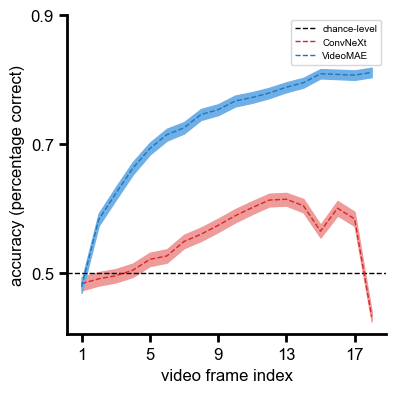

In [2]:
"""
Behavioral Decoding Analysis of Object Category for ANN models

This script visualizes histograms of models based on their behavioral performance. It processes pre-computed accuracy scores.

The analysis includes:
1. Loading accuracy scores from HDF5 file
2. Computing the highest accuracy across time bins for each model
3. Generating a histogram comparing static (image-based) vs dynamic (video-based) ANN models, with vertical lines indicating mean performance for each group and chance-level performance.

Key outputs:
- decode_obj_cat_linear_model_histogram.pdf: Histogram comparing model performance on object category decoding task, with mean performance indicated for static vs dynamic models.
"""

import sys
sys.path.append('../')

from utils.plot_utils import journal_figure_pdf, journal_figure

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import scienceplots

plt.style.use(['nature'])

static_models = {
    "images_moving2_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
}

dynamic_models = {
    "images_moving2_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE']
}

models = {**static_models, **dynamic_models}

scores_path = '../../scores/figure2'

values_dir = []
errors_dir = []

methods_names = list(models.keys())
for name in methods_names:

    file_rgb_dir = h5py.File(f'{scores_path}/{name}/decode_ann_obj_dir_linear.h5', 'r')
    i1_per_time_dir = np.array(file_rgb_dir[f'i1_all'])

    i1_per_time_dir_ = np.nanmean(i1_per_time_dir, axis=-1)
    i1_per_time_dir_ = np.nanmean(i1_per_time_dir_, axis=0)
    i1_per_time_dir = np.nanmean(i1_per_time_dir_, axis=-1)

    values_dir.append(i1_per_time_dir)
    errors_dir.append(np.nanstd(i1_per_time_dir_, axis=-1) / np.sqrt(i1_per_time_dir_.shape[-1]))

values_dir_ff = np.array(values_dir[:len(static_models)])
errors_dir_ff = np.array(errors_dir[:len(static_models)])

values_dir_dd = np.array(values_dir[len(static_models):])
errors_dir_dd = np.array(errors_dir[len(static_models):])


plt.figure(figsize=(4, 5))

plt.errorbar(range(values_dir_ff.shape[1]), np.nanmean(values_dir_ff, 0), 
            #yerr=accuracy_per_time_rgb_rnn_se,
            c='tab:red',
            #capsize=5, 
            #marker='o',
            linestyle='--',
            label=f'ConvNeXt'
            )
plt.fill_between(range(values_dir_ff.shape[1]), 
                 np.nanmean(values_dir_ff, 0) - np.nanmean(errors_dir_ff, 0) , 
                 np.nanmean(values_dir_ff, 0) + np.nanmean(errors_dir_ff, 0), 
                 color="#ee9b9a")  

plt.errorbar(range(values_dir_dd.shape[1]), np.nanmean(values_dir_dd, 0), 
            #yerr=accuracy_per_time_rgb_rnn_se,
            c='tab:blue',
            #capsize=5, 
            #marker='o',
            linestyle='--',
            label=f'VideoMAE'
            )
plt.fill_between(range(values_dir_dd.shape[1]), 
                 np.nanmean(values_dir_dd, 0) - np.nanmean(errors_dir_dd, 0) , 
                 np.nanmean(values_dir_dd, 0) + np.nanmean(errors_dir_dd, 0), 
                 color="#6eafe8")  

plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label=f'chance-level')

plt.xlabel('video frame index', fontsize=12)
plt.ylabel('accuracy (percentage correct)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
#plt.ylim(0.47, 1.0)
plt.yticks(np.arange(0.5, 0.91, 0.2), fontsize=6)
plt.xticks(np.arange(0, 18, 4), np.arange(1, 19, 4), fontsize=6)

journal_figure(do_save=True, filename=f'../../plots/figure2_decode_obj_dir_linear_model-ff-dd.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure2_decode_obj_dir_linear_model-ff-dd.pdf')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


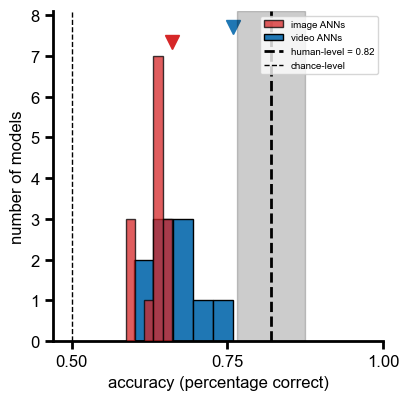

image ANNs mean accuracy: 0.63 ± 0.02
video ANNs mean accuracy: 0.67 ± 0.04
image ANNs - video ANNs mean difference: -0.04
image ANNs max accuracy: 0.66
video ANNs max accuracy: 0.76
t-test between image and video ANNs: TtestResult(statistic=np.float64(-2.493367092760378), pvalue=np.float64(0.020664171554804732), df=np.float64(22.0))


In [3]:
"""
Behavioral Decoding Analysis of Object Motion Speed for ANN models

This script visualizes histograms of models based on their behavioral performance. It processes pre-computed accuracy scores.

The analysis includes:
1. Loading accuracy scores from HDF5 file
2. Computing the highest accuracy across time bins for each model
3. Generating a histogram comparing static (image-based) vs dynamic (video-based) ANN models, with vertical lines indicating mean performance for each group and chance-level performance.

Key outputs:
- decode_obj_speed_linear_model_histogram.pdf: Histogram comparing model performance on object motion speed decoding task, with mean performance indicated for static vs dynamic models.
"""

import sys
sys.path.append('../')

from utils.plot_utils import journal_figure_pdf

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import scienceplots

plt.style.use(['nature'])

static_models = {
    "images_velocity_alexnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'AlexNet'], 
    "images_velocity_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
    "images_velocity_densenet121_features_srp_1000_10.h5" : ['f', 'tab:red', 'DenseNet-121'], 
    "images_velocity_efficientnet_b0_features_srp_1000_10.h5" : ['f', 'tab:red', 'EfficientNet-B0'], 
    "images_velocity_hiera_features_srp_1000_10.h5" : ['f', 'tab:red', 'Hiera'], 
    "images_velocity_inception_v3_features_srp_1000_10.h5" : ['f', 'tab:red', 'Inception-V3'], 
    "images_velocity_pnasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'PNASNet'], 
    "images_velocity_resnet50_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50'], 
    "images_velocity_resnet50_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50-SSL'], 
    "images_velocity_vit_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT'], 
    "images_velocity_vit_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT-SSL'], 
    "images_velocity_nasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'NASNet'], 
    "images_velocity_rgc_intermediate_features_ff_srp_1000_10.h5" : ['ri', 'tab:red', 'ConvRNN-F'],
    "images_velocity_CORnet-S_IT_features_srp_1000_10.h5" : ['ri', 'tab:red', 'CORnet-S'],
}

dynamic_models = {
    "images_velocity_c2d_r50-blocks.4.res_blocks.5.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_velocity_i3d_r50-blocks.5.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_velocity_x3d_xs-blocks.4.res_blocks.6.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_velocity_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_velocity_slow_r50-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_velocity_timesformer_ssv2-timesformer.encoder.layer.8_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_velocity_timesformer-timesformer.encoder.layer.11_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_velocity_videomamba_ssv2-layers.10.mixer_features_srp_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_velocity_videomamba-layers.10.mixer_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_velocity_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
}


models = {**static_models, **dynamic_models}

scores_path = '../../scores/figure2'

values = []
errors = []
methods_names = list(models.keys())
for name in methods_names:
    file_rgb = h5py.File(f'{scores_path}/{name}/decode_ann_obj_speed_linear.h5', 'r')
    i1_per_time = np.array(file_rgb[f'i1_all'])

    i1_per_time = np.nanmean(i1_per_time, axis=-1)
    i1_per_time = np.nanmean(i1_per_time, axis=0)

    i1_per_time_m = np.nanmean(i1_per_time, axis=-1)
    #print(name, np.nanmax(i1_per_time_m))
    max_id = np.argmax(i1_per_time_m)
    i1_per_time = i1_per_time[max_id]

    i1_per_time_mean = np.nanmean(i1_per_time, axis=0)
    i1_per_time_se = np.nanstd(i1_per_time, axis=0) / np.sqrt(i1_per_time.shape[0])

    values.append(i1_per_time_mean)
    errors.append(i1_per_time_se)


values_ff = np.array(values[:len(static_models)])
values_dd = np.array(values[len(static_models):])

plt.figure(figsize=(4, 5))
plt.hist(values_ff, bins=5, color='tab:red', alpha=.75, label='image ANNs', edgecolor='black', zorder=3)
plt.hist(values_dd, bins=5, color='tab:blue',  label='video ANNs', edgecolor='black', zorder=1)

plt.plot(np.nanmax(values_ff), plt.ylim()[1] * 1.0, marker='v', color='tab:red', markersize=10, zorder=3)

plt.plot(np.nanmax(values_dd), plt.ylim()[1] * 1.0, marker='v', color='tab:blue', markersize=10, zorder=3)

human_c = 0.82 
human_err = 0.055 
plt.axvline(human_c, color='black', linestyle='--', linewidth=2, label=f'human-level = {np.round(human_c, 2)}')
plt.axvspan(human_c - human_err, human_c + human_err, color='black', alpha=0.2, zorder=3)


plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label=f'chance-level')

plt.xlabel('accuracy (percentage correct)', fontsize=12)
plt.ylabel('number of models', fontsize=12)
plt.xlim(0.47, 1.0)
plt.xticks(np.arange(0.5, 1.01, 0.25), fontsize=6)
plt.legend(fontsize=10)
plt.tight_layout()

journal_figure(do_save=True, filename=f'../../plots/figure2_decode_obj_speed_linear_model_histogram.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure2_decode_obj_speed_linear_model_histogram.pdf')

plt.show()

print(f'image ANNs mean accuracy: {np.nanmean(values_ff):.2f} ± {np.nanstd(values_ff):.2f}')
print(f'video ANNs mean accuracy: {np.nanmean(values_dd):.2f} ± {np.nanstd(values_dd):.2f}')
print(f'image ANNs - video ANNs mean difference: {np.nanmean(values_ff) - np.nanmean(values_dd):.2f}')
print(f'image ANNs max accuracy: {np.nanmax(values_ff):.2f}')
print(f'video ANNs max accuracy: {np.nanmax(values_dd):.2f}')
print(f't-test between image and video ANNs: {scipy.stats.ttest_ind(values_ff, values_dd)}')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


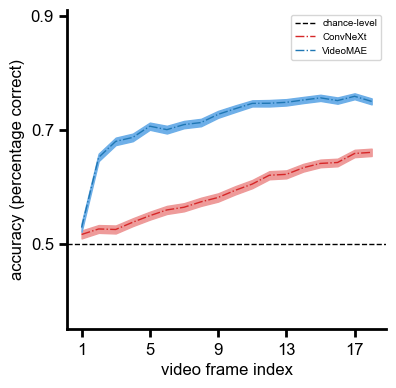

In [4]:
"""
Behavioral Decoding Analysis of Object Category for ANN models

This script visualizes histograms of models based on their behavioral performance. It processes pre-computed accuracy scores.

The analysis includes:
1. Loading accuracy scores from HDF5 file
2. Computing the highest accuracy across time bins for each model
3. Generating a histogram comparing static (image-based) vs dynamic (video-based) ANN models, with vertical lines indicating mean performance for each group and chance-level performance.

Key outputs:
- decode_obj_cat_linear_model_histogram.pdf: Histogram comparing model performance on object category decoding task, with mean performance indicated for static vs dynamic models.
"""

import sys
sys.path.append('../')

from utils.plot_utils import journal_figure_pdf, journal_figure

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import scienceplots

plt.style.use(['nature'])

static_models = {
    "images_moving2_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
}

dynamic_models = {
    "images_moving2_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE']
}

models = {**static_models, **dynamic_models}

scores_path = '../../scores/figure2'

values_speed = []
errors_speed = []

methods_names = list(models.keys())
for name in methods_names:

    file_rgb_speed = h5py.File(f'{scores_path}/{name.replace('images_moving2', 'images_velocity')}/decode_ann_obj_speed_linear.h5', 'r')
    i1_per_time_speed = np.array(file_rgb_speed[f'i1_all'])

    i1_per_time_speed_ = np.nanmean(i1_per_time_speed, axis=-1)
    i1_per_time_speed_ = np.nanmean(i1_per_time_speed_, axis=0)
    i1_per_time_speed = np.nanmean(i1_per_time_speed_, axis=-1)

    values_speed.append(i1_per_time_speed)
    errors_speed.append(np.nanstd(i1_per_time_speed_, axis=-1) / np.sqrt(i1_per_time_speed_.shape[-1]))


values_dir_ff = np.array(values_dir[:len(static_models)])
values_speed_ff = np.array(values_speed[:len(static_models)])
errors_dir_ff = np.array(errors_dir[:len(static_models)])
errors_speed_ff = np.array(errors_speed[:len(static_models)])

values_dir_dd = np.array(values_dir[len(static_models):])
values_speed_dd = np.array(values_speed[len(static_models):])
errors_dir_dd = np.array(errors_dir[len(static_models):])
errors_speed_dd = np.array(errors_speed[len(static_models):])


plt.figure(figsize=(4, 5))


plt.errorbar(range(values_speed_ff.shape[1]), np.nanmean(values_speed_ff, 0), 
            #yerr=accuracy_per_time_rgb_rnn_se,
            c='tab:red',
            #capsize=5, 
            #marker='o',
            linestyle='-.',
            label=f'ConvNeXt'
            )
plt.fill_between(range(values_speed_ff.shape[1]), 
                 np.nanmean(values_speed_ff, 0) - np.nanmean(errors_speed_ff, 0), 
                 np.nanmean(values_speed_ff, 0) + np.nanmean(errors_speed_ff, 0), 
                 color="#ee9b9a")  
plt.errorbar(range(values_speed_dd.shape[1]), np.nanmean(values_speed_dd, 0), 
            #yerr=accuracy_per_time_rgb_rnn_se,
            c='tab:blue',
            #capsize=5, 
            #marker='o',
            linestyle='-.',
            label=f'VideoMAE'
            )
plt.fill_between(range(values_speed_dd.shape[1]), 
                 np.nanmean(values_speed_dd, 0) - np.nanmean(errors_speed_dd, 0), 
                 np.nanmean(values_speed_dd, 0) + np.nanmean(errors_speed_dd, 0), 
                 color="#6eafe8")  


plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label=f'chance-level')

plt.xlabel('video frame index', fontsize=12)
plt.ylabel('accuracy (percentage correct)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
#plt.ylim(0.47, 1.0)
plt.yticks(np.arange(0.3, 0.91, 0.2), fontsize=6)
plt.ylim([0.35, 0.91])
plt.xticks(np.arange(0, 18, 4), np.arange(1, 19, 4), fontsize=6)

journal_figure(do_save=True, filename=f'../../plots/figure2_decode_obj_speed_linear_model-ff-dd.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure2_decode_obj_speed_linear_model-ff-dd.pdf')

plt.show()